#A/B TESTING CNN FOOD101
Perbandingan Model 6242 vs Model 6401

1. Latar Belakang

Tujuan pengujian adalah membandingkan performa dua model Convolutional Neural Network (CNN) yang dikembangkan menggunakan dataset Food101. Kedua model dilatih menggunakan arsitektur dan dataset yang sama, namun memiliki perbedaan pada proses pelatihannya, yaitu jumlah epoch yang digunakan selama training.

Model 1: Nutrivision CNN 6242
Dilatih hingga 63 epoch.
Model 2: Nutrivision CNN 6401
Dilatih hingga 99 epoch.

Pengujian dilakukan pada test set Food101 yang sama untuk memastikan kedua model dievaluasi pada kondisi yang setara. Variabel yang diuji dalam eksperimen ini adalah jumlah epoch pelatihan, dengan tujuan untuk mengetahui apakah pelatihan yang lebih lama menghasilkan performa klasifikasi yang lebih baik.

Evaluasi dilakukan menggunakan metrik Accuracy, Precision, Recall, dan F1-Score. Hasil pengujian akan digunakan untuk menentukan model dengan performa terbaik yang akan diimplementasikan pada sistem Nutrivision.

2. Hipotesis

Pengujian hipotesis dilakukan untuk mengetahui apakah Nutrivision CNN 6401 memiliki performa yang lebih baik dibandingkan Nutrivision CNN 6242 pada dataset uji yang sama.

-
Hipotesis Nol (H₀)

Performa Model 6401 tidak lebih baik daripada Model 6242.

H0: P6401 ≤ P6242
	​
-
Hipotesis Alternatif (H₁)

Performa Model 6401 lebih baik daripada Model 6242.

H1 :P6401 > P6242


-

dengan P6401 dan P6242 merepresentasikan performa masing-masing model berdasarkan metrik evaluasi yang digunakan pada data pengujian.

Hipotesis ini digunakan untuk menguji apakah peningkatan performa yang diperoleh Model 6401 setelah dilatih hingga 99 epoch memberikan hasil yang lebih baik dibandingkan Model 6242 yang dilatih hingga 63 epoch.

- Menentukan Jumlah Sampel Pengujian

Menentukan jumlah minimum gambar yang diperlukan untuk melakukan pengujian A/B terhadap dua model CNN secara representatif.

Parameter
Confidence Level = 95%
Margin of Error = 10%
Proporsi (p) = 0.5

Nilai p=0.5 digunakan karena memberikan ukuran sampel paling konservatif (terbesar).

Rumus Cochran:

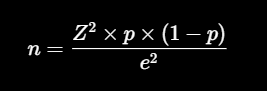
	​


Keterangan:

n = ukuran sampel minimum

Z = nilai z-score berdasarkan confidence level

p = proporsi

e = margin of error

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Menginstal library yang dibutuhkan
!pip install -q statsmodels

In [ ]:
# Mengimpor library Python yang diperlukan untuk analisis data, model, dan evaluasi
import os
import json
import zipfile
import numpy as np
import math
import pandas as pd
import requests
import time

import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from statsmodels.stats.contingency_tables import mcnemar

In [ ]:
# daftar nama kelas makanan yang akan digunakan
food_classes = [
    "pizza",
    "hamburger",
    "hot_dog",
    "ramen",
    "sushi",
    "tacos",
    "waffles",
    "pancakes",
    "ice_cream",
    "cheesecake",
    "donuts",
    "apple_pie",
    "chicken wings",
    "fried rice",
    "lasagna",
    "omelette",
    "nachos",
    "spaghetti_bolognese",
    "steak",
    "caesar salad"
]

In [ ]:
# Kode untuk mendownload gambar dari Pexels (mengambil gambar untuk test)
""" # Code untuk mendownload gambar dari Pexels
BASE_DIR = "/content/drive/MyDrive/ab_testing/test"

os.makedirs(BASE_DIR, exist_ok=True)

headers = {
    "Authorization": PEXELS_API_KEY
}

for food in food_classes:

    print(f"\nDownloading {food}...")

    class_dir = os.path.join(
        BASE_DIR,
        food.replace(" ", "_")
    )

    os.makedirs(class_dir, exist_ok=True)

    search_url = (
        f"https://api.pexels.com/v1/search"
        f"?query={food} food"
        f"&per_page=5"
    )

    response = requests.get(
        search_url,
        headers=headers
    )

    if response.status_code != 200:
        print("API Error:", response.status_code)
        continue

    photos = response.json().get("photos", [])

    downloaded = 0

    for photo in photos:

        try:

            img_url = photo["src"]["large"]

            img_data = requests.get(
                img_url,
                timeout=20
            ).content

            filename = os.path.join(
                class_dir,
                f"{food.replace(' ','_')}_{downloaded+1}.jpg"
            )

            with open(filename, "wb") as f:
                f.write(img_data)

            downloaded += 1

        except Exception as e:
            print("Failed:", e)

    print(f"Saved {downloaded} images")

    time.sleep(1)"""

' # Code untuk mendownload gambar dari Pexels\nBASE_DIR = "/content/drive/MyDrive/ab_testing/test"\n\nos.makedirs(BASE_DIR, exist_ok=True)\n\nheaders = {\n    "Authorization": PEXELS_API_KEY\n}\n\nfor food in food_classes:\n\n    print(f"\nDownloading {food}...")\n\n    class_dir = os.path.join(\n        BASE_DIR,\n        food.replace(" ", "_")\n    )\n\n    os.makedirs(class_dir, exist_ok=True)\n\n    search_url = (\n        f"https://api.pexels.com/v1/search"\n        f"?query={food} food"\n        f"&per_page=5"\n    )\n\n    response = requests.get(\n        search_url,\n        headers=headers\n    )\n\n    if response.status_code != 200:\n        print("API Error:", response.status_code)\n        continue\n\n    photos = response.json().get("photos", [])\n\n    downloaded = 0\n\n    for photo in photos:\n\n        try:\n\n            img_url = photo["src"]["large"]\n\n            img_data = requests.get(\n                img_url,\n                timeout=20\n            ).conten

In [ ]:
# Memeriksa jumlah gambar yang tersedia untuk pengujian di setiap kelas makanan
BASE_DIR = "/content/drive/MyDrive/ab_testing/test"

total = 0

for cls in sorted(os.listdir(BASE_DIR)):

    cls_path = os.path.join(BASE_DIR, cls)

    if os.path.isdir(cls_path):

        count = len([
            f for f in os.listdir(cls_path)
            if f.lower().endswith(
                ('.jpg', '.jpeg', '.png')
            )
        ])

        print(f"{cls}: {count}")
        total += count

print("\nTOTAL:", total)

apple_pie: 5
caesar_salad: 5
cheesecake: 5
chicken_wings: 5
donuts: 5
fried_rice: 5
hamburger: 5
hot_dog: 5
ice_cream: 5
lasagna: 5
nachos: 5
omelette: 5
pancakes: 5
pizza: 5
ramen: 5
spaghetti_bolognese: 5
steak: 5
sushi: 5
tacos: 5
waffles: 5

TOTAL: 100


In [ ]:
# Menghitung ukuran sampel minimum yang diperlukan untuk pengujian A/B
confidence_level = 0.95
z = 1.96
p = 0.5
e = 0.10

n = (z**2 * p * (1-p)) / (e**2)

print(f"Ukuran sampel minimum: {math.ceil(n)} gambar")

Ukuran sampel minimum: 97 gambar


In [ ]:
# Mendefinisikan jalur file ZIP untuk kedua model dan direktori data uji
ZIP_6242 = "/content/drive/MyDrive/ab_testing/nutrivison_food101_ram_safe 6242.zip"
ZIP_6401 = "/content/drive/MyDrive/ab_testing/model_ai (2).zip"

TEST_DIR = "/content/drive/MyDrive/ab_testing/test"

In [ ]:
# Mengekstrak file ZIP kedua model ke direktori masing-masing
with zipfile.ZipFile(ZIP_6242, 'r') as zip_ref:
    zip_ref.extractall('/content/model_6242')

with zipfile.ZipFile(ZIP_6401, 'r') as zip_ref:
    zip_ref.extractall('/content/model_6401')

print("Extraction selesai")

Extraction selesai


In [ ]:
# Mencetak daftar semua file dalam direktori model 6242 untuk verifikasi
for root, dirs, files in os.walk('/content/model_6242'):
    for f in files:
        print(os.path.join(root, f))

/content/model_6242/nutrivison_food101_ram_safe 6242/nutrition_table_internal.csv
/content/model_6242/nutrivison_food101_ram_safe 6242/class_names.json
/content/model_6242/nutrivison_food101_ram_safe 6242/best_nutrivision_food101_ram_safe.keras
/content/model_6242/nutrivison_food101_ram_safe 6242/training_log.csv
/content/model_6242/nutrivison_food101_ram_safe 6242/final_nutrivision_food101_ram_safe.keras


In [ ]:
# Mencetak daftar semua file dalam direktori model 6401 untuk verifikasi
for root, dirs, files in os.walk('/content/model_6401'):
    for f in files:
        print(os.path.join(root, f))

/content/model_6401/6401 00077/__pycache__/main.cpython-314.pyc
/content/model_6401/6401 00077/__pycache__/main.cpython-311.pyc
/content/model_6401/6401 00077/__pycache__/main.cpython-39.pyc
/content/model_6401/6401 00077/backend/artifacts/akg_pregnant.csv
/content/model_6401/6401 00077/backend/artifacts/nutrition_table_cleaned.csv
/content/model_6401/6401 00077/backend/artifacts/akg_normal.csv
/content/model_6401/6401 00077/backend/artifacts/class_names.json
/content/model_6401/6401 00077/backend/artifacts/training_log.csv
/content/model_6401/6401 00077/backend/artifacts/best_nutrivision_cnn_food101_akg.keras
/content/model_6401/6401 00077/backend/artifacts/akg_breastfeeding.csv
/content/model_6401/6401 00077/backend/app/main.py
/content/model_6401/6401 00077/backend/app/__init__.py
/content/model_6401/6401 00077/backend/app/__pycache__/main.cpython-311.pyc
/content/model_6401/6401 00077/backend/app/__pycache__/__init__.cpython-311.pyc
/content/model_6401/6401 00077/backend/app/routes

In [ ]:
# Memuat Model 1 (nutrivison_food101_ram_safe 6242)
#Model 1
model_6242 = tf.keras.models.load_model(
    "/content/model_6242/nutrivison_food101_ram_safe 6242/best_nutrivision_food101_ram_safe.keras"
)

In [ ]:
# Mencari lokasi panggilan 'load_model' dalam file-file model 6401 untuk mengetahui path model yang benar
!grep -R "load_model" "/content/model_6401"

grep: /content/model_6401/6401 00077/__pycache__/main.cpython-314.pyc: binary file matches
grep: /content/model_6401/6401 00077/__pycache__/main.cpython-311.pyc: binary file matches
grep: /content/model_6401/6401 00077/__pycache__/main.cpython-39.pyc: binary file matches
grep: /content/model_6401/6401 00077/backend/app/services/__pycache__/model_service.cpython-311.pyc: binary file matches
/content/model_6401/6401 00077/backend/app/services/model_service.py:model = keras.models.load_model(


In [ ]:
# Membaca dan menampilkan isi dari file model_service.py dari model 6401
with open("/content/model_6401/6401 00077/backend/app/services/model_service.py", "r") as f:
    print(f.read())

import io
import json
import numpy as np
import pandas as pd
from PIL import Image
import keras

MODEL_PATH = "artifacts/best_nutrivision_cnn_food101_akg.keras"
CLASS_NAMES_PATH = "artifacts/class_names.json"
NUTRITION_TABLE_PATH = "artifacts/nutrition_table_cleaned.csv"


@keras.saving.register_keras_serializable(
    package="NutriVision",
    name="NutritionFromClassProbability"
)
class NutritionFromClassProbability(keras.layers.Layer):
    def __init__(self, nutrition_table_norm, **kwargs):
        super().__init__(**kwargs)
        self.nutrition_table_norm = np.array(nutrition_table_norm, dtype="float32")

    def build(self, input_shape):
        self.nutrition_table = self.add_weight(
            name="nutrition_table",
            shape=self.nutrition_table_norm.shape,
            initializer=keras.initializers.Constant(self.nutrition_table_norm),
            trainable=False,
        )
        super().build(input_shape)

    def call(self, class_probs):
        return keras.op

In [ ]:
# Mendefinisikan dan mendaftarkan custom layer 'NutritionFromClassProbability' untuk Keras
import keras

@keras.saving.register_keras_serializable(
    package="NutriVision",
    name="NutritionFromClassProbability"
)
class NutritionFromClassProbability(keras.layers.Layer):
    def __init__(self, nutrition_table_norm, **kwargs):
        super().__init__(**kwargs)
        self.nutrition_table_norm = np.array(
            nutrition_table_norm,
            dtype="float32"
        )

    def build(self, input_shape):
        self.nutrition_table = self.add_weight(
            name="nutrition_table",
            shape=self.nutrition_table_norm.shape,
            initializer=keras.initializers.Constant(
                self.nutrition_table_norm
            ),
            trainable=False,
        )
        super().build(input_shape)

    def call(self, class_probs):
        return keras.ops.matmul(
            class_probs,
            self.nutrition_table
        )

    def get_config(self):
        config = super().get_config()
        config.update({
            "nutrition_table_norm":
            self.nutrition_table_norm.tolist()
        })
        return config

    @classmethod
    def from_config(cls, config):
        nutrition_table_norm = config.pop(
            "nutrition_table_norm"
        )
        return cls(
            nutrition_table_norm=nutrition_table_norm,
            **config
        )

keras.saving.get_custom_objects()[
    "NutritionFromClassProbability"
] = NutritionFromClassProbability

keras.saving.get_custom_objects()[
    "NutriVision>NutritionFromClassProbability"
] = NutritionFromClassProbability

In [ ]:
# Memuat Model 2 (best_nutrivision_cnn_food101_akg.keras) menggunakan Keras
model_6401 = keras.models.load_model(
    "/content/model_6401/6401 00077/backend/artifacts/best_nutrivision_cnn_food101_akg.keras",
    compile=False,
    safe_mode=False
)

In [ ]:
# Memuat nama-nama kelas dari file JSON untuk Model 6242
with open(
    "/content/model_6242/nutrivison_food101_ram_safe 6242/class_names.json",
    "r"
) as f:
    class_names = json.load(f)

print("Jumlah kelas:", len(class_names))

Jumlah kelas: 101


In [ ]:
# Memuat data set pengujian gambar dari direktori yang ditentukan
IMG_SIZE = (224,224)
BATCH_SIZE = 32

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 100 files belonging to 20 classes.


In [ ]:
# Mengambil label asli (ground truth) dari dataset pengujian
y_true = []

for images, labels in test_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

print(y_true.shape)

(100,)


In [ ]:
# Melakukan prediksi menggunakan Model 1 (model_6242) pada dataset pengujian
pred_6242 = model_6242.predict(test_ds)

print(type(pred_6242))
print(np.shape(pred_6242))

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 776ms/step
<class 'dict'>
()


In [ ]:
# Melakukan prediksi menggunakan Model 2 (model_6401) pada dataset pengujian dan memproses hasilnya
pred_6401 = model_6401.predict(test_ds)

if isinstance(pred_6401, dict):
    class_probs_6401 = pred_6401["class_output"]
else:
    class_probs_6401 = pred_6401

y_pred_6401 = np.argmax(class_probs_6401, axis=1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 921ms/step


In [ ]:
# Mengambil probabilitas kelas dan menentukan prediksi akhir untuk Model 1
#Prediksi Model 1
class_probs = pred_6242["class_output"]
y_pred_6242 = np.argmax(class_probs, axis=1)

In [ ]:
# Mengambil probabilitas kelas dan menentukan prediksi akhir untuk Model 2
# ambil class output
class_probs_6401 = pred_6401["class_output"]

# baru argmax
y_pred_6401 = np.argmax(class_probs_6401, axis=1)

Menyelaraskan Prediksi Model dengan Label Dataset Uji

Karena model dilatih menggunakan 101 kelas dan dataset uji hanya berisi 20 kelas, perbandingan langsung antara label prediksi dengan label sebenarnya akan menyebabkan semua prediksi dianggap salah. Untuk mengatasi masalah ini, kita perlu memetakan prediksi 101 kelas dari model ke label 20 kelas pada dataset uji kita.

1.  **Identifikasi Nama Kelas Uji**: Dapatkan daftar nama kelas yang berurutan dari `test_ds` (yang sesuai dengan subdirektori di `TEST_DIR`). Nama-nama ini berhubungan dengan label integer `y_true` (0-19).
2.  **Nama Kelas Model**: Gunakan variabel `class_names`, yang berisi 101 nama kelas yang digunakan untuk melatih model.
3.  **Buat Pemetaan**: Untuk setiap prediksi dari model:
    *   Jika nama kelas yang diprediksi oleh model ada dalam nama kelas dataset uji, petakan ke label integer yang sesuai (0-19).
    *   Jika model memprediksi kelas yang *tidak ada* dalam dataset uji, berikan label "salah" khusus (misalnya, 20) untuk memastikan prediksi tersebut dihitung sebagai kesalahan klasifikasi.

In [ ]:
# Mengidentifikasi nama kelas dari dataset uji dan model, lalu membuat fungsi untuk memetakan prediksi model ke label kelas uji.
# Get the ordered list of class names from the test dataset
test_ds_class_names = test_ds.class_names
print(f"Test Dataset Class Names ({len(test_ds_class_names)}): {test_ds_class_names}")

# The models' 101 class names are already loaded in the 'class_names' variable
model_101_class_names = class_names
print(f"Model Class Names ({len(model_101_class_names)}): First 5: {model_101_class_names[:5]}, Last 5: {model_101_class_names[-5:]}")

# Create a reverse mapping from test class name to its index for quick lookup
test_name_to_idx = {name: idx for idx, name in enumerate(test_ds_class_names)}

# Function to map model predictions (101 classes) to test labels (20 classes)
def map_model_preds_to_test_labels(
    y_preds_original,
    model_101_class_names,
    test_name_to_idx,
    num_test_classes
):
    mapped_preds = []
    for model_pred_idx in y_preds_original:
        if model_pred_idx < len(model_101_class_names):
            model_predicted_class_name = model_101_class_names[model_pred_idx]
            if model_predicted_class_name in test_name_to_idx:
                # Map to the correct index in the 20-class test set
                mapped_preds.append(test_name_to_idx[model_predicted_class_name])
            else:
                # Model predicted a class not in our 20 test classes, so it's incorrect
                # Assign an index outside the 0-19 range to mark it as wrong
                mapped_preds.append(num_test_classes) # e.g., 20
        else:
            # Should not happen with argmax, but as a safeguard for out-of-bounds indices
            mapped_preds.append(num_test_classes)
    return np.array(mapped_preds)

num_test_classes = len(test_ds_class_names)

y_pred_6242_mapped = map_model_preds_to_test_labels(
    y_pred_6242,
    model_101_class_names,
    test_name_to_idx,
    num_test_classes
)
y_pred_6401_mapped = map_model_preds_to_test_labels(
    y_pred_6401,
    model_101_class_names,
    test_name_to_idx,
    num_test_classes
)

print(f"Original y_pred_6242 sample: {y_pred_6242[:5]}")
print(f"Mapped y_pred_6242 sample:   {y_pred_6242_mapped[:5]}")
print(f"Original y_pred_6401 sample: {y_pred_6401[:5]}")
print(f"Mapped y_pred_6401 sample:   {y_pred_6401_mapped[:5]}")

Test Dataset Class Names (20): ['apple_pie', 'caesar_salad', 'cheesecake', 'chicken_wings', 'donuts', 'fried_rice', 'hamburger', 'hot_dog', 'ice_cream', 'lasagna', 'nachos', 'omelette', 'pancakes', 'pizza', 'ramen', 'spaghetti_bolognese', 'steak', 'sushi', 'tacos', 'waffles']
Model Class Names (101): First 5: ['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare'], Last 5: ['tacos', 'takoyaki', 'tiramisu', 'tuna_tartare', 'waffles']
Original y_pred_6242 sample: [ 21  22 100  42  42]
Mapped y_pred_6242 sample:   [20 20 19 20 20]
Original y_pred_6401 sample: [29 23 78 42 42]
Mapped y_pred_6401 sample:   [20 20 20 20 20]


In [ ]:
# Mendefinisikan fungsi untuk mengevaluasi model berdasarkan metrik akurasi, presisi, recall, dan F1-score
#Metrik Evaluasi
def evaluate_model(y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average='macro'
    )

    recall = recall_score(
        y_true,
        y_pred,
        average='macro'
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average='macro'
    )

    return accuracy, precision, recall, f1

In [ ]:
# Mengevaluasi Model 1 dengan prediksi yang belum dipetakan
#Evaluasi Model 1
acc1, prec1, rec1, f11 = evaluate_model(
    y_true,
    y_pred_6242
)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Mengevaluasi ulang Model 1 menggunakan prediksi yang sudah dipetakan ke kelas uji 20
# Re-evaluate Model 1 with mapped predictions
acc1, prec1, rec1, f11 = evaluate_model(
    y_true,
    y_pred_6242_mapped
)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Mengevaluasi Model 2 dengan prediksi yang belum dipetakan
acc2, prec2, rec2, f12 = evaluate_model(
    y_true,
    y_pred_6401
)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Mengevaluasi ulang Model 2 menggunakan prediksi yang sudah dipetakan ke kelas uji 20
acc2, prec2, rec2, f12 = evaluate_model(
    y_true,
    y_pred_6401_mapped
)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Membuat dan menampilkan tabel hasil evaluasi metrik (Accuracy, Precision, Recall, F1) untuk kedua model
results = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ],
    "Model_6242":[
        acc1,
        prec1,
        rec1,
        f11
    ],
    "Model_6401":[
        acc2,
        prec2,
        rec2,
        f12
    ]
})

results

,Metric,Model_6242,Model_6401
0,Accuracy,0.250000,0.280000
1,Precision,0.547619,0.634127
2,Recall,0.238095,0.266667
3,F1,0.319539,0.358239


In [ ]:
# Menghitung hasil prediksi benar atau salah untuk Model 1 dan Model 2
correct_6242 = y_pred_6242 == y_true
correct_6401 = y_pred_6401 == y_true

In [ ]:
# Menghitung ulang prediksi benar/salah untuk tes McNemar, menggunakan prediksi yang sudah dipetakan
correct_6242 = y_pred_6242_mapped == y_true
correct_6401 = y_pred_6401_mapped == y_true

In [ ]:
# Membuat tabel kontingensi untuk uji McNemar berdasarkan hasil prediksi benar/salah dari kedua model
table = [[0,0],
         [0,0]]

for a,b in zip(correct_6242, correct_6401):

    if a and b:
        table[0][0] += 1

    elif a and not b:
        table[0][1] += 1

    elif not a and b:
        table[1][0] += 1

    else:
        table[1][1] += 1

table = np.array(table)

table

array([[13, 12],
       [15, 60]])

In [ ]:
total_samples_mcnemar = np.sum(table)

if total_samples_mcnemar > 0:
    percentage_both_correct = (table[0][0] / total_samples_mcnemar) * 100
    percentage_6242_correct_6401_incorrect = (table[0][1] / total_samples_mcnemar) * 100
    percentage_6242_incorrect_6401_correct = (table[1][0] / total_samples_mcnemar) * 100
    percentage_both_incorrect = (table[1][1] / total_samples_mcnemar) * 100

    print(f"\nPersentase hasil McNemar:")
    print(f"  Kedua Model Benar: {percentage_both_correct:.2f}%")
    print(f"  Model 6242 Benar, Model 6401 Salah: {percentage_6242_correct_6401_incorrect:.2f}%")
    print(f"  Model 6242 Salah, Model 6401 Benar: {percentage_6242_incorrect_6401_correct:.2f}%")
    print(f"  Kedua Model Salah: {percentage_both_incorrect:.2f}%")
else:
    print("Tidak ada sampel untuk perhitungan McNemar.")


Persentase hasil McNemar:
  Kedua Model Benar: 13.00%
  Model 6242 Benar, Model 6401 Salah: 12.00%
  Model 6242 Salah, Model 6401 Benar: 15.00%
  Kedua Model Salah: 60.00%


In [ ]:
# Melakukan uji McNemar pada tabel kontingensi untuk membandingkan signifikansi perbedaan performa kedua model
#McNemar
result = mcnemar(
    table,
    exact=False,
    correction=True
)

print("Statistic :", result.statistic)
print("P-value   :", result.pvalue)

Statistic : 0.14814814814814814
P-value   : 0.7003113729368903


In [ ]:
# Menentukan keputusan pengujian berdasarkan nilai p-value dari uji McNemar dan tingkat signifikansi alpha untuk uji satu sisi
# Hasil Keputusan Testing (Uji Satu Sisi)
alpha = 0.05

# Untuk uji satu sisi (H1: Model 6401 lebih baik dari Model 6242),
# kita perlu memeriksa arah perbedaan dan membagi p-value dengan 2.
# table[1][0] adalah kasus di mana Model 6242 salah dan Model 6401 benar.
# table[0][1] adalah kasus di mana Model 6242 benar dan Model 6401 salah.

is_model_6401_better_in_disagreement = table[1][0] > table[0][1]

# p-value untuk uji satu sisi
p_value_one_sided = result.pvalue / 2

if is_model_6401_better_in_disagreement and p_value_one_sided < alpha:

    print("KEPUTUSAN : Tolak H0")

    print(
        "Terdapat bukti statistik bahwa performa Model 6401 lebih baik dari Model 6242."
    )

else:

    print("KEPUTUSAN : Gagal Menolak H0")

    print(
        "Tidak terdapat bukti statistik yang cukup bahwa performa Model 6401 lebih baik dari Model 6242."
    )


KEPUTUSAN : Gagal Menolak H0
Tidak terdapat bukti statistik yang cukup bahwa performa Model 6401 lebih baik dari Model 6242.


In [ ]:
# Menentukan model terbaik berdasarkan akurasi, jika Model 6401 lebih akurat, maka itu adalah yang terbaik, jika tidak, Model 6242 yang terbaik.
if acc2 > acc1:
    print("Model terbaik : 6401")
else:
    print("Model terbaik : 6242")

Model terbaik : 6401


In [ ]:
# Menghitung persentase perbedaan akurasi antara kedua model
if acc1 != 0:
    percentage_diff_accuracy = ((acc2 - acc1) / acc1) * 100
    print(f"Persentase perbedaan akurasi: {percentage_diff_accuracy:.2f}%")
else:
    print("Akurasi Model 6242 adalah 0, tidak dapat menghitung persentase perbedaan.")

Persentase perbedaan akurasi: 12.00%


## Kesimpulan Hasil Uji A/B dan Rekomendasi

### Hasil Uji McNemar: Gagal Menolak H0

Berdasarkan Uji McNemar satu sisi dengan tingkat signifikansi `alpha = 0.05`, ab_testing gagal menolak Hipotesis Nol (H0). Tidak ada bukti yang cukup kuat untuk menyatakan bahwa performa Model 6401 secara signifikan lebih baik dibandingkan Model 6242. Meskipun Model 6401 menunjukkan peningkatan akurasi deskriptif sebesar 12% (dari 25% menjadi 28%), perbedaan ini tidak mencapai ambang batas signifikansi statistik yang kita tetapkan.

Interpretasi Perbedaan

*   **Signifikansi Statistik**: Uji McNemar menunjukkan bahwa perbedaan performa yang diamati bisa jadi hanya karena kebetulan atau variasi acak, bukan karena perbedaan fundamental antara kedua model pada ukuran sampel yang digunakan.
*   **Signifikansi Praktis**: Meskipun secara statistik tidak signifikan, Model 6401 *secara deskriptif* tetap menunjukkan akurasi yang lebih tinggi (28% berbanding 25%) serta metrik Precision, Recall, dan F1-Score yang lebih baik. Dalam konteks aplikasi image classification, peningkatan 3% dalam akurasi dapat dianggap bernilai.

### Model Terbaik dan Rekomendasi

Meskipun uji statistik tidak memberikan dasar yang kuat untuk mengklaim Model 6401 *secara signifikan* lebih baik, jika kita hanya melihat metrik performa:

*   **Model Terbaik (berdasarkan metrik deskriptif): Model 6401**

Model 6401 menunjukkan akurasi (28%), Precision (0.63), Recall (0.27), dan F1-Score (0.36) yang lebih tinggi dibandingkan Model 6242. Dalam situasi di mana keputusan harus dibuat, Model 6401 adalah pilihan yang lebih baik dari kedua model ini, asalkan pertimbangan praktis mendukungnya.

### Keputusan Implementasi

Karena Model 6401 memiliki keunggulan performa yang jelas secara praktis dan tidak menimbulkan biaya atau kerumitan implementasi yang signifikan, maka **Model 6401 tetap digunakan** sebagai model yang dipilih. Namun, perlu disadari bahwa keunggulannya belum *terbukti secara statistik* pada dataset uji ini.